In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import date

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [34]:
load_dotenv()
#DATA_DIR = os.environ["DATA_DIR"]
# Baseline period for Impact
BASELINE_PERIOD = slice("1996-01-01", "2025-12-31")
# Define Forecast Months
FC_MONTHS = [9, 10, 11, 12, 1, 2]
FC_PERIOD = slice("2026-09-01", "2027-02-28")

config = analysis_utils.ImpactConfig( version = "v260910",
                                     baseline_period=BASELINE_PERIOD, 
                                     polygons_path= os.environ["POREALLAS_REGIONS_POLYGONS_URI"],
                                     socioeconomics_path= os.environ["POREALLAS_SOCIOECONOMICS_URI"],
                                     rate=False, 
                                     months = FC_MONTHS,
                                     hotonly = "net", 
                                     dims = ['number', 'sample'])

# Define Forecast
EFFECTS_URI = "/home/emily_zuetell/projects/poreallas/data/v20260909_effects_with_betas.zarr" # Can be any effects datatree

In [35]:
# Projection Effects
effect = xr.open_datatree(EFFECTS_URI, consolidated=False)

In [36]:
### Log baseline period and impact calculation
rate_l = "rate" if config.rate else "total"
baseline_tag = analysis_utils._baseline_tag(config.baseline_period)

In [37]:
# Compute impact: forecast - baseline
impact = analysis_utils.compute_impact(
    effect.chunk({dim: -1 for dim in config.dims}),
    config,
    ensemble=True,
)
# Use only the defined 6-months
impact = impact.sel(month=config.months)

In [38]:
# Aggregate Impact Regions to group_level
group_level = 'ISO' #IR: Impact region, # ADM1: State level, # ISO: Country level
impact, merge_key, base_cols = analysis_utils.aggregate_impact(impact, config, group_level)

In [39]:
def fetch_country_boundaries():
    url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
    return gpd.read_file(url)[["NAME", "ADM0_A3", "geometry"]]

def join_to_countries(gdf, countries):
    return gpd.sjoin(gdf.to_crs(countries.crs), countries, how="left", predicate="intersects")

countries = fetch_country_boundaries()

In [40]:
# Ordered by Population In Need (Projected March 2027)
df_fewsnet = ['Sudan', 'Pakistan', 'Nigeria', 'Dem. Rep. Congo', 
              'Yemen', 'Afghanistan', 'South Sudan',
              'Syria', 'Somalia', 'Colombia', 'Haiti',
              'Zimbabwe', 'Uganda', 'Kenya', 'Guatemala', 
              'Venezuela', 'Ukraine', 'Madagascar', 'Malawi',
              'Mozambique', 'Chad', 'Niger', 'Cameroon', 'Lebanon',
              'Angola', 'Sri Lanka', 'Burkina Faso', 'Nepal',
              'Central African Republic', 'Zambia', 'Mali']

In [41]:
df = impact.mean(dim = config.dims).sum(dim = 'month').to_dataframe(name='impact').reset_index()
df = df.drop(columns = ['year'])
iso_to_name = countries.set_index("ADM0_A3")["NAME"].to_dict()
df["country"] = df["ISO"].map(iso_to_name)
# S. Sudan
df.loc[df['ISO'] == 'SSD', 'country'] = 'South Sudan'

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


In [42]:
rank_map = {country: i + 1 for i, country in enumerate(df_fewsnet)}
df["fewsnet_rank"] = df["country"].map(rank_map)

In [43]:
df.sort_values('impact', ascending = False).head(10).to_csv("impact_fewsnet_net.csv")

In [44]:
df.sort_values('impact', ascending = False).head(10)

,ISO,impact,country,fewsnet_rank
166,NGA,21014.215429,Nigeria,3.0
195,SDN,16501.754801,Sudan,1.0
164,NER,8918.453841,Niger,22.0
220,TCD,7146.219358,Chad,21.0
210,SSD,5281.650857,South Sudan,7.0
21,BFA,3946.611526,Burkina Faso,27.0
148,MLI,3836.968461,Mali,31.0
154,MOZ,2765.596760,Mozambique,20.0
84,GHA,2572.016011,Ghana,NaN
48,COD,2399.830890,Dem. Rep. Congo,4.0


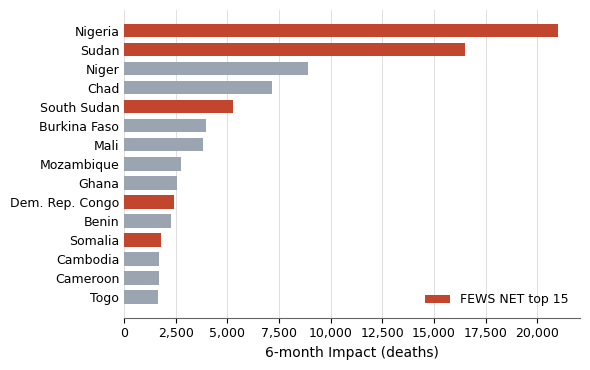

In [45]:
top = df.sort_values('impact', ascending=False).head(15)
y = np.arange(len(top))
in_top10 = (top['fewsnet_rank'] <= 15).values

highlight, base = '#C2452D', '#9AA5B1'  # still distinguishable in grayscale

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.barh(y[in_top10], top['impact'][in_top10], color=highlight, height=0.7,
        label='FEWS NET top 15')
ax.barh(y[~in_top10], top['impact'][~in_top10], color=base, height=0.7)

ax.set_yticks(y, top['country'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('6-month Impact (deaths)', fontsize=10)
ax.xaxis.set_major_formatter('{x:,.0f}')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', length=0)

ax.grid(axis='x', color='0.85', lw=0.6)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left'):
    ax.spines[side].set_visible(False)
ax.spines['bottom'].set_color('0.4')

ax.legend(frameon=False, fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig('top15_impact.png', dpi = 300, bbox_inches='tight')  # or .png with dpi=300